# HyperParameterOptimisation for Approval Predict

## Imports and required libraries

In [1]:
# Core
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Sklearn: split, metrics, model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, make_scorer
)

# Pipeline
from sklearn.pipeline import Pipeline

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier
)
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

## Update Working Directory

In [2]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict/jupyter_notebooks'

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict'

## Load data

In [5]:
root = os.getcwd()
file_path = Path(root) / "outputs" / "datasets" / "collection" / "loan_approval.csv"
df = pd.read_csv(file_path).drop(['name', 'city'], axis=1)

df['loan_approved'] = df['loan_approved'].astype(int)

reduced_features = ['years_employed', 'loan_amount', 'income']
X = df[reduced_features].copy()
y = df['loan_approved'].copy()

X.head(3), y.head(3)

(   years_employed  loan_amount  income
 0              27        39698  113810
 1              28        15446   44592
 2              13        11189   33278,
 0    0
 1    0
 2    0
 Name: loan_approved, dtype: int64)

## Split train and test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Train/Test Shapes:")
X_train.shape, y_train.shape, X_test.shape, y_test.shape

Train/Test Shapes:


((1600, 3), (1600,), (400, 3), (400,))

## Handle Class Imbalance

After SMOTE: (1808, 3) (1808,)


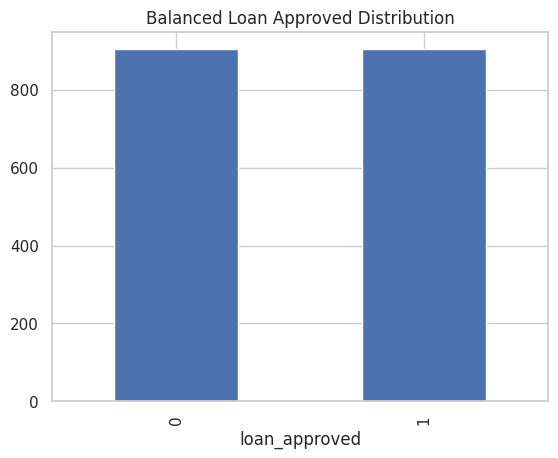

In [82]:
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.shape)

y_train_bal.value_counts().plot(kind='bar', title='Balanced Loan Approved Distribution')
plt.show()

## ML Pipeline

In [8]:
def PipelineClf(model):
    return Pipeline([
        ("model", model)
    ])

In [9]:
def PipelineClf(model):
    """
    Builds a pipeline for hyperparameter optimisation.
    """
    return Pipeline([
        ("model", model),
    ])

## HyperParameter Optimisation

In [10]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineClf(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

In [11]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    prediction = pipeline.predict(X)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confusion_matrix(y_true=prediction, y_pred=y),
        columns=[["Actual " + sub for sub in label_map]],
        index=[["Prediction " + sub for sub in label_map]]
    ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

First round of hyperparameter optimisation using AdaBoostClassifier

In [12]:
model = {"AdaBoostClassifier": AdaBoostClassifier(random_state=42)}

https://www.youtube.com/watch?v=JmXnztjULnQ 
Tune its key parameters (such as n_estimators and learning_rate) to improve its generalisation.
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
Scikit-learn details default parameters of 50 for n_estimators and 1 for learning rate. I adjusted these values

In [13]:
params_search_ada = {
    "AdaBoostClassifier": {
        "model__n_estimators": [50,25,80,150],
        "model__learning_rate": [1,0.1, 2]
    }
}

n_estimators: Number of trees in the ensemble. How many small trees the model builds and combines to make predictions.
learning_rate: Weight of each tree’s contribution. How strongly each tree changes the model’s final prediction.

In [14]:
search = HyperparameterOptimizationSearch(models=model, params=params_search_ada)
search.fit(X_train, y_train,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [15]:
extensive_grid_search_summary, extensive_grid_search_pipelines = search.score_summary(sort_by='mean_score')

best_model = extensive_grid_search_summary.iloc[0,0]
best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = extensive_grid_search_pipelines[best_model].best_estimator_

best_parameters

{'model__learning_rate': 1, 'model__n_estimators': 25}

In [16]:
clf_performance(X_train=X_train, y_train=y_train,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             642             264
Prediction Approved             262             432


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.71      0.71      0.71       904
    Approved       0.62      0.62      0.62       696

    accuracy                           0.67      1600
   macro avg       0.67      0.67      0.67      1600
weighted avg       0.67      0.67      0.67      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             138              67
Prediction Approved              79             116


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.67      0.64      0.65       217
    Approved       0.59      0.63      0.61       183

    accuracy                   

In [17]:
params_search_ada = {
    "AdaBoostClassifier": {
        "model__n_estimators": [10,25,80,150],
        "model__learning_rate": [1,0.5, 2]
    }
}

In [18]:
search = HyperparameterOptimizationSearch(models=model, params=params_search_ada)
search.fit(X_train, y_train,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [19]:
extensive_grid_search_summary, extensive_grid_search_pipelines = search.score_summary(sort_by='mean_score')

best_model = extensive_grid_search_summary.iloc[0,0]
best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = extensive_grid_search_pipelines[best_model].best_estimator_

best_parameters

{'model__learning_rate': 1, 'model__n_estimators': 10}

In [20]:
clf_performance(X_train=X_train, y_train=y_train,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             581             233
Prediction Approved             323             463


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.71      0.64      0.68       904
    Approved       0.59      0.67      0.62       696

    accuracy                           0.65      1600
   macro avg       0.65      0.65      0.65      1600
weighted avg       0.66      0.65      0.65      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             128              63
Prediction Approved              89             120


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.67      0.59      0.63       217
    Approved       0.57      0.66      0.61       183

    accuracy                   

In [21]:
ada_best = AdaBoostClassifier(
    learning_rate=1.2,
    n_estimators=15,
    random_state=42
)

In [22]:
pipeline_ada = Pipeline([
    ('model', ada_best)
])

In [23]:
pipeline_ada.fit(X_train, y_train)

Pipeline(steps=[('model',
                 AdaBoostClassifier(learning_rate=1.2, n_estimators=15,
                                    random_state=42))])

In [24]:
y_pred_train = pipeline_ada.predict(X_train)
y_pred_test = pipeline_ada.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train, target_names=["Rejected","Approved"]))

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test, target_names=["Rejected","Approved"]))

#### Train Set ####

[[624 280]
 [272 424]]
              precision    recall  f1-score   support

    Rejected       0.70      0.69      0.69       904
    Approved       0.60      0.61      0.61       696

    accuracy                           0.66      1600
   macro avg       0.65      0.65      0.65      1600
weighted avg       0.66      0.66      0.66      1600

#### Test Set ####

[[138  79]
 [ 70 113]]
              precision    recall  f1-score   support

    Rejected       0.66      0.64      0.65       217
    Approved       0.59      0.62      0.60       183

    accuracy                           0.63       400
   macro avg       0.63      0.63      0.63       400
weighted avg       0.63      0.63      0.63       400



## RandomForestClassifier

In [25]:
model = {"RandomForestClassifier": RandomForestClassifier(random_state=42)}

In [26]:
params_search = {
    "RandomForestClassifier": {
        'model__n_estimators': [100,50,140],
        'model__max_depth': [None,4, 15],
        'model__min_samples_split': [2,50],
        'model__min_samples_leaf': [1,50],
        'model__max_leaf_nodes': [None,50],
    },
}

In [27]:
search = HyperparameterOptimizationSearch(models=model, params=params_search)
search.fit(X_train, y_train,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [28]:
extensive_grid_search_summary, extensive_grid_search_pipelines = search.score_summary(sort_by='mean_score')

best_model = extensive_grid_search_summary.iloc[0,0]
best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = extensive_grid_search_pipelines[best_model].best_estimator_

best_parameters

{'model__max_depth': 15,
 'model__max_leaf_nodes': None,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [29]:
clf_performance(X_train=X_train, y_train=y_train,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             904               8
Prediction Approved               0             688


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.99      1.00      1.00       904
    Approved       1.00      0.99      0.99       696

    accuracy                           0.99      1600
   macro avg       1.00      0.99      0.99      1600
weighted avg       1.00      0.99      0.99      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             145              95
Prediction Approved              72              88


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.60      0.67      0.63       217
    Approved       0.55      0.48      0.51       183

    accuracy                   

In [48]:
rf_best = RandomForestClassifier(
    max_depth=7,
    max_leaf_nodes=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

In [49]:
pipeline_rf = Pipeline([
    ('model', rf_best)
])

In [50]:
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=7,
                                        random_state=42))])

In [51]:
clf_performance(
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    pipeline=pipeline_rf,
    label_map=["Rejected", "Approved"]
)

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             660             138
Prediction Approved             244             558


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.83      0.73      0.78       904
    Approved       0.70      0.80      0.74       696

    accuracy                           0.76      1600
   macro avg       0.76      0.77      0.76      1600
weighted avg       0.77      0.76      0.76      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             122              59
Prediction Approved              95             124


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.67      0.56      0.61       217
    Approved       0.57      0.68      0.62       183

    accuracy                   

In [52]:
y_pred_train = pipeline_rf.predict(X_train)
y_pred_test = pipeline_rf.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train, target_names=["Rejected","Approved"]))

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test, target_names=["Rejected","Approved"]))

#### Train Set ####

[[660 244]
 [138 558]]
              precision    recall  f1-score   support

    Rejected       0.83      0.73      0.78       904
    Approved       0.70      0.80      0.74       696

    accuracy                           0.76      1600
   macro avg       0.76      0.77      0.76      1600
weighted avg       0.77      0.76      0.76      1600

#### Test Set ####

[[122  95]
 [ 59 124]]
              precision    recall  f1-score   support

    Rejected       0.67      0.56      0.61       217
    Approved       0.57      0.68      0.62       183

    accuracy                           0.61       400
   macro avg       0.62      0.62      0.61       400
weighted avg       0.62      0.61      0.61       400



## XGBClassifier

In [83]:
model = {"XGBClassifier": XGBClassifier(random_state=42)}

In [84]:
params_search_xgb = {
    "XGBClassifier": {
        "model__n_estimators": [30, 80, 200],
        "model__max_depth": [None, 6, 15],
        "model__learning_rate": [0.1, 0.01, 0.001],
        "model__gamma": [0, 0.1],
    }
}

In [85]:
search = HyperparameterOptimizationSearch(models=model, params=params_search_xgb)

search.fit(
    X_train_bal, y_train_bal,
    scoring=make_scorer(recall_score, pos_label=1),
    n_jobs=-1, cv=5
)


Running GridSearchCV for XGBClassifier 

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return is_int or is_bool or is_float or is_

KeyboardInterrupt: 

In [56]:
extensive_grid_search_summary, extensive_grid_search_pipelines = search.score_summary(sort_by='mean_score')

best_model = extensive_grid_search_summary.iloc[0,0]
best_parameters = extensive_grid_search_pipelines[best_model].best_params_
classification_pipeline = extensive_grid_search_pipelines[best_model].best_estimator_

best_parameters

{'model__gamma': 0,
 'model__learning_rate': 0.1,
 'model__max_depth': 15,
 'model__n_estimators': 200}

In [86]:
clf_performance(
    X_train=X_train_bal, y_train=y_train_bal,
    X_test=X_test, y_test=y_test,
    pipeline=classification_pipeline,
    label_map=["Rejected", "Approved"]
)

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             904              48
Prediction Approved               0             856


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.95      1.00      0.97       904
    Approved       1.00      0.95      0.97       904

    accuracy                           0.97      1808
   macro avg       0.97      0.97      0.97      1808
weighted avg       0.97      0.97      0.97      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             136             100
Prediction Approved              81              83


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.58      0.63      0.60       217
    Approved       0.51      0.45      0.48       183

    accuracy                   

/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return is_int or is_bool or is_float or is_

In [87]:
xgb_best = XGBClassifier(
    gamma=0,
    learning_rate=0.2,
    max_depth=None,
    n_estimators=80,
    random_state=42,
    eval_metric='logloss',
)

In [88]:
pipeline_xgb = Pipeline([
    ('model', xgb_best)
])

In [89]:
pipeline_xgb.fit(X_train, y_train)

/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return is_int or is_bool or is_float or is_

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=0, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, n_estimators=80,
                               n_jobs=None, num_parallel_tree=None,
                               predictor=None, random_state=42, ...))])

In [90]:
clf_performance(
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    pipeline=pipeline_xgb,
    label_map=["Rejected", "Approved"]
)

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             886              64
Prediction Approved              18             632


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.93      0.98      0.96       904
    Approved       0.97      0.91      0.94       696

    accuracy                           0.95      1600
   macro avg       0.95      0.94      0.95      1600
weighted avg       0.95      0.95      0.95      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             146              93
Prediction Approved              71              90


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.61      0.67      0.64       217
    Approved       0.56      0.49      0.52       183

    accuracy                   

/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return is_int or is_bool or is_float or is_

In [91]:
y_pred_train = pipeline_xgb.predict(X_train)
y_pred_test = pipeline_xgb.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train, target_names=["Rejected","Approved"]))

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test, target_names=["Rejected","Approved"]))

#### Train Set ####

[[886  18]
 [ 64 632]]
              precision    recall  f1-score   support

    Rejected       0.93      0.98      0.96       904
    Approved       0.97      0.91      0.94       696

    accuracy                           0.95      1600
   macro avg       0.95      0.94      0.95      1600
weighted avg       0.95      0.95      0.95      1600

#### Test Set ####

[[146  71]
 [ 93  90]]
              precision    recall  f1-score   support

    Rejected       0.61      0.67      0.64       217
    Approved       0.56      0.49      0.52       183

    accuracy                           0.59       400
   macro avg       0.58      0.58      0.58       400
weighted avg       0.59      0.59      0.59       400



/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return is_int or is_bool or is_float or is_